<a href="https://colab.research.google.com/github/xKevin441/SIS420-IA-Kevin-Tarqui/blob/main/Laboratorio%2002%20Regresi%C3%B3n%20log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 02


# Descripción del Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cargar los datos

In [22]:
# El CSV no tiene encabezado; se asignan nombres manualmente.
col_names = ['win', 'cluster_id', 'game_mode', 'game_type'] + \
            [f'hero_{i}' for i in range(1, 114)]

# Se utilizan los datasets de entrenamiento y prueba
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/dota2Train.csv', header=None, names=col_names)
df_test  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/dota2Test.csv',  header=None, names=col_names)

print(f'Train : {df_train.shape[0]:>7,} filas × {df_train.shape[1]} columnas')
print(f'Test  : {df_test.shape[0]:>7,} filas × {df_test.shape[1]} columnas')
df_train.head(3)

Train :  92,650 filas × 117 columnas
Test  :  10,294 filas × 117 columnas


,win,cluster_id,game_mode,game_type,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,...,hero_104,hero_105,hero_106,hero_107,hero_108,hero_109,hero_110,hero_111,hero_112,hero_113
0,-1,223,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,152,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0
2,1,131,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0


## Tratamiento de valores y columnas

In [23]:
# Valores nulos
print('Valores nulos en train:', df_train.isnull().sum().sum())
print('Valores nulos en test: ', df_test.isnull().sum().sum())

Valores nulos en train: 0
Valores nulos en test:  0


Train — Victoria  (1) : 48,782  (52.7%)
Train — Derrota  (-1) : 43,868  (47.3%)


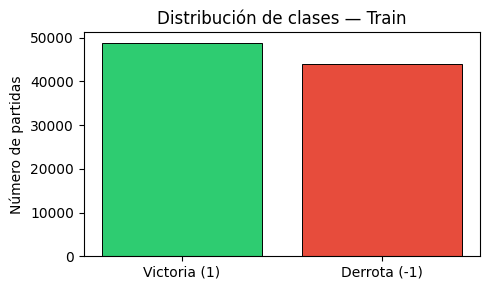

In [24]:
# Distribución de la variable objetivo
win_counts = df_train['win'].value_counts().sort_index()
wins_train   = (df_train['win'] ==  1).sum()
losses_train = (df_train['win'] == -1).sum()
total_train  = len(df_train)

print(f'Train — Victoria  (1) : {wins_train:>6,}  ({wins_train/total_train*100:.1f}%)')
print(f'Train — Derrota  (-1) : {losses_train:>6,}  ({losses_train/total_train*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Victoria (1)', 'Derrota (-1)'], [wins_train, losses_train],
       color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.7)
ax.set_title('Distribución de clases — Train')
ax.set_ylabel('Número de partidas')
plt.tight_layout()
plt.show()

### Separar variable X e y

In [25]:
# Eliminar las columnas win y cluster_id
DROP_COLS = ['win', 'cluster_id']

# Train
y_train_raw = df_train['win'].values
X_train_df  = df_train.drop(columns=DROP_COLS)

# Test
y_test_raw  = df_test['win'].values
X_test_df   = df_test.drop(columns=DROP_COLS)

print('Columnas de características:', X_train_df.shape[1])

Columnas de características: 115


In [26]:
#  Convertir y a (0, 1)
# Se convierte: 1 → 1 (victoria equipo 1),  -1 → 0 (derrota equipo 1)
y_train = ((y_train_raw + 1) / 2).astype(int)
y_test  = ((y_test_raw  + 1) / 2).astype(int)
print('Etiquetas únicas tras conversión:', np.unique(y_train))

#Convertir a arrays NumPy
X_train = X_train_df.values.astype(float)   # (92650, n_features)
X_test  = X_test_df.values.astype(float)    # (10293, n_features)

print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')

Etiquetas únicas tras conversión: [0 1]
X_train : (92650, 115)
y_train : (92650,)
X_test  : (10294, 115)
y_test  : (10294,)


## Normalización de valores
las columnas `game_mode` y `game_type` son variables categóricas codificadas numéricamente con valores más grandes. Para que el **descenso por gradiente converja estable y eficientemente**, aplicamos **estandarización (Z-score)** a esas columnas continuas, dejando intactas las columnas de héroe (ya acotadas).

In [29]:
def featureNormalize(X, cols):
    X_norm = X.copy()

    mu    = np.mean(X[:, cols], axis=0)
    sigma = np.std(X[:, cols], axis=0)

    sigma_safe = np.where(sigma == 0, 1, sigma)

    X_norm[:, cols] = (X[:, cols] - mu) / sigma_safe

    return X_norm, mu, sigma

In [30]:
feature_cols  = list(X_train_df.columns)
cols_to_norm  = [feature_cols.index('game_mode'),
                 feature_cols.index('game_type')]

X_train_norm, mu, sigma = featureNormalize(X_train, cols_to_norm)

# Aplicar parámetros de train al test (evitar data leakage)
sigma_safe  = np.where(sigma == 0, 1, sigma)
X_test_norm = X_test.copy()
X_test_norm[:, cols_to_norm] = (X_test[:, cols_to_norm] - mu) / sigma_safe

## Implementación
### Función sigmoidea

In [17]:
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))

    return g

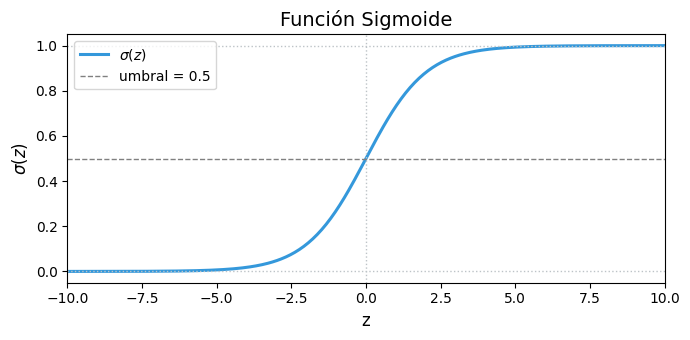

In [19]:
z_vals  = np.linspace(-10, 10, 400)
sig_out = sigmoid(z_vals)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(z_vals, sig_out, color='#3498db', linewidth=2.2, label=r'$\sigma(z)$')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='umbral = 0.5')
ax.axhline(1.0, color='#bdc3c7', linestyle=':', linewidth=1)
ax.axhline(0.0, color='#bdc3c7', linestyle=':', linewidth=1)
ax.axvline(0,   color='#bdc3c7', linestyle=':', linewidth=1)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel(r'$\sigma(z)$', fontsize=12)
ax.set_title('Función Sigmoide', fontsize=14)
ax.legend()
ax.set_xlim(-10, 10)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

#### Función de Costo y Gradiente

La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [31]:
def calcularCosto(theta, X, y):
    m = y.size

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [48]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [35]:
def agregar_intercepcion(X):
    m   = X.shape[0]
    ones = np.ones((m, 1))
    return np.hstack([ones, X])

X_train_b = agregar_intercepcion(X_train_norm)   # (92650, n+1)
X_test_b  = agregar_intercepcion(X_test_norm)    # (10293, n+1)

print(f'X_train con bias: {X_train_b.shape}')
print(f'X_test  con bias: {X_test_b.shape}')

X_train con bias: (92650, 116)
X_test  con bias: (10294, 116)


### Determinar valores de Theta

In [53]:
ALPHA      = 0.1
NUM_ITERS  = 1000

n_features = X_train_b.shape[1]
theta = np.zeros(n_features).reshape(-1)
print(f'Número de parámetros θ (incluyendo bias): {n_features}')
print(f'Tasa de aprendizaje  α : {ALPHA}')
print(f'Iteraciones            : {NUM_ITERS}')
print('\n── Entrenando ──────────────────────────────────────────────')

theta, J_history = descensoGradiente(theta, X_train_b, y_train, ALPHA, NUM_ITERS)

print(f'\nCosto inicial  : {J_history[0]:.6f}')
print(f'Costo final    : {J_history[-1]:.6f}')

Número de parámetros θ (incluyendo bias): 116
Tasa de aprendizaje  α : 0.1
Iteraciones            : 1000

── Entrenando ──────────────────────────────────────────────

Costo inicial  : 0.692913
Costo final    : 0.663718


theta calculado por el descenso por el gradiente: [ 0.1140099   0.00056008 -0.00528057 -0.09187966  0.14313169 -0.09337407
  0.05679047  0.21018093  0.17158488  0.03653814  0.05560824  0.2168112
  0.01907659 -0.12123529 -0.12803123 -0.14740016  0.09189865 -0.07900352
  0.02040022 -0.07061324  0.20333385 -0.16114499  0.10169725 -0.24043675
  0.1924831  -0.00811465  0.         -0.20007505 -0.04716229  0.12453341
  0.08186972  0.09671526  0.03232483  0.11413584  0.21846304  0.08357435
 -0.1347028   0.04162441  0.26594807  0.12192577 -0.02226238 -0.26798703
  0.08224082  0.051195    0.23785412 -0.07958106  0.08580309 -0.05038378
 -0.15887261 -0.02392054  0.17983777  0.00673466  0.05199885  0.01129307
 -0.11480703 -0.2789266   0.01575238  0.00138266 -0.12350521  0.41937084
 -0.21661563 -0.11325983  0.03275481 -0.19683054 -0.03433617 -0.00189424
  0.05581057 -0.11161322 -0.05696432  0.21879609  0.0517374  -0.10751327
  0.16856793  0.10486032 -0.11838218 -0.01115631 -0.16745132  0.1934953
 -0

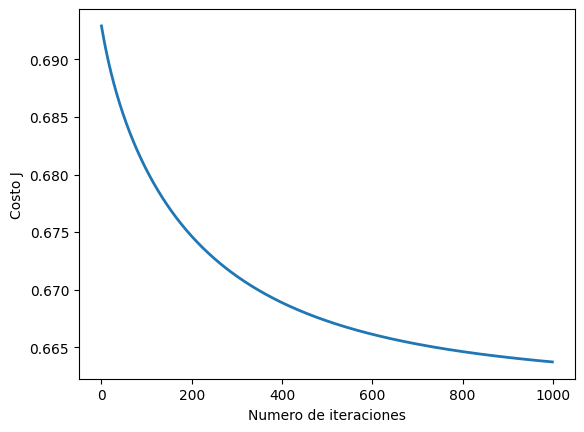

In [54]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

## Etapa de prueba

In [56]:
def predict_proba(X, theta):
    return sigmoid(X @ theta)


def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)


# Predicciones sobre el conjunto de prueba
y_prob_test = predict_proba(X_test_b, theta)
y_pred_test = predict(X_test_b, theta)

print(f'Ejemplos en test       : {len(y_test):,}')
print(f'Pred. Victoria (1)     : {y_pred_test.sum():,}')
print(f'Pred. Derrota  (0)     : {(1 - y_pred_test).sum():,}')

Ejemplos en test       : 10,294
Pred. Victoria (1)     : 6,190
Pred. Derrota  (0)     : 4,104


In [ ]:
print(X_test)
print(theta)

[[2.000e+00 1.220e+02 7.600e+01 2.700e+01 2.000e+02 3.590e+01 4.830e-01
  2.600e+01]
 [6.000e+00 1.250e+02 7.800e+01 3.100e+01 0.000e+00 2.760e+01 5.650e-01
  4.900e+01]
 [1.000e+00 1.680e+02 8.800e+01 2.900e+01 0.000e+00 3.500e+01 9.050e-01
  5.200e+01]
 [2.000e+00 1.290e+02 0.000e+00 0.000e+00 0.000e+00 3.850e+01 3.040e-01
  4.100e+01]
 [4.000e+00 1.100e+02 7.600e+01 2.000e+01 1.000e+02 2.840e+01 1.180e-01
  2.700e+01]
 [6.000e+00 8.000e+01 8.000e+01 3.600e+01 0.000e+00 3.980e+01 1.770e-01
  2.800e+01]
 [1.000e+01 1.150e+02 0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.610e-01
  3.000e+01]
 [2.000e+00 1.270e+02 4.600e+01 2.100e+01 3.350e+02 3.440e+01 1.760e-01
  2.200e+01]
 [9.000e+00 1.640e+02 7.800e+01 0.000e+00 0.000e+00 3.280e+01 1.480e-01
  4.500e+01]
 [2.000e+00 9.300e+01 6.400e+01 3.200e+01 1.600e+02 3.800e+01 6.740e-01
  2.300e+01]
 [3.000e+00 1.580e+02 6.400e+01 1.300e+01 3.870e+02 3.120e+01 2.950e-01
  2.400e+01]
 [5.000e+00 1.260e+02 7.800e+01 2.700e+01 2.200e+01 2.960e+01 4.3

In [ ]:
X_test, y_test = data[700:, 0:8], data[700:, 8]
print(X_test)

[[2.000e+00 1.220e+02 7.600e+01 2.700e+01 2.000e+02 3.590e+01 4.830e-01
  2.600e+01]
 [6.000e+00 1.250e+02 7.800e+01 3.100e+01 0.000e+00 2.760e+01 5.650e-01
  4.900e+01]
 [1.000e+00 1.680e+02 8.800e+01 2.900e+01 0.000e+00 3.500e+01 9.050e-01
  5.200e+01]
 [2.000e+00 1.290e+02 0.000e+00 0.000e+00 0.000e+00 3.850e+01 3.040e-01
  4.100e+01]
 [4.000e+00 1.100e+02 7.600e+01 2.000e+01 1.000e+02 2.840e+01 1.180e-01
  2.700e+01]
 [6.000e+00 8.000e+01 8.000e+01 3.600e+01 0.000e+00 3.980e+01 1.770e-01
  2.800e+01]
 [1.000e+01 1.150e+02 0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.610e-01
  3.000e+01]
 [2.000e+00 1.270e+02 4.600e+01 2.100e+01 3.350e+02 3.440e+01 1.760e-01
  2.200e+01]
 [9.000e+00 1.640e+02 7.800e+01 0.000e+00 0.000e+00 3.280e+01 1.480e-01
  4.500e+01]
 [2.000e+00 9.300e+01 6.400e+01 3.200e+01 1.600e+02 3.800e+01 6.740e-01
  2.300e+01]
 [3.000e+00 1.580e+02 6.400e+01 1.300e+01 3.870e+02 3.120e+01 2.950e-01
  2.400e+01]
 [5.000e+00 1.260e+02 7.800e+01 2.700e+01 2.200e+01 2.960e+01 4.3

In [ ]:
# comprobar si las personas del dataset de prueba tienen diabetes
# X_array = [1, 1, 80, 66, 28, 0, 33.4, 0.675, 46]
X_test_norm, mu, sigma = featureNormalize(X_test)
m, n = X_test_norm.shape
X_test_norm = np.concatenate([np.ones((m, 1)), X_test_norm], axis=1)
aprueba = sigmoid(np.dot(X_test_norm, theta))   # Se debe cambiar esto
print(aprueba)
# print('Una persona con los siguientes datos [1, 1, 80, 66, 28, 0, 33.4, 0.675, 46] tiene como probabilida de ser diabetico:{:.0f}'.format(aprueba))

[0.24068779 0.29793088 0.749956   0.63950921 0.08054249 0.12231261
 0.04581837 0.22987986 0.7068058  0.17028703 0.39102364 0.26360027
 0.75829999 0.12160479 0.06943463 0.91381072 0.77457854 0.14947583
 0.16179514 0.20846036 0.04451752 0.1873096  0.3207527  0.32029351
 0.10452408 0.29311353 0.18549048 0.24225523 0.2987718  0.05704111
 0.17919783 0.17318061 0.84243357 0.09719447 0.07662018 0.15129685
 0.09672947 0.09165167 0.14714531 0.18195937 0.76878953 0.13921104
 0.07292324 0.61028052 0.93714289 0.25973291 0.68670014 0.32243354
 0.81678608 0.47221552 0.52320713 0.24312529 0.07636664 0.68687958
 0.67796631 0.43096122 0.41750003 0.25272995 0.12955762 0.87267224
 0.07887183 0.93208007 0.05701497 0.26094105 0.2764486  0.13042909
 0.22009479 0.05401845]


In [ ]:
print(X_test_norm)
print(theta)
predict = sigmoid(np.dot(X_test_norm[0], theta))   # Se debe cambiar esto
print(predict)
# print(y_test)

[[ 1.00000000e+00 -5.93923442e-01 -8.66614987e-02  2.66369944e-01
   3.25181539e-01  1.08429332e+00  4.04104086e-01  2.08731024e-01
  -7.37974548e-01]
 [ 1.00000000e+00  5.76708269e-01  1.61230695e-02  3.82853264e-01
   5.91595330e-01 -7.07491509e-01 -7.66719046e-01  5.27080090e-01
   1.27281324e+00]
 [ 1.00000000e+00 -8.86581369e-01  1.48936855e+00  9.65269862e-01
   4.58388434e-01 -7.07491509e-01  2.77147361e-01  1.84706403e+00
   1.53508991e+00]
 [ 1.00000000e+00 -5.93923442e-01  1.53169160e-01 -4.15999620e+00
  -1.47311155e+00 -7.07491509e-01  7.70867959e-01 -4.86201695e-01
   5.73408795e-01]
 [ 1.00000000e+00 -8.60758611e-03 -4.97799772e-01  2.66369944e-01
  -1.41042595e-01  1.88400905e-01 -6.53868624e-01 -1.20831055e+00
  -6.50548992e-01]
 [ 1.00000000e+00  5.76708269e-01 -1.52564545e+00  4.99336584e-01
   9.24612568e-01 -7.07491509e-01  9.54249896e-01 -9.79254518e-01
  -5.63123435e-01]
 [ 1.00000000e+00  1.74733998e+00 -3.26492158e-01 -4.15999620e+00
  -1.47311155e+00 -7.0749150